> ### Public copy — demo data
>
> The 2024 survey this project was built on belongs to the client and is not redistributable, so
> it is **not in this repository**. In its place, `data/raw/engagement_survey_2024.xlsx` is written
> by `scripts/make_demo_workbook.py`: the same sheet name, the same 22 columns and 42 rows, the
> same category headers, the same two 1-10 items and the same delta-from-company-mean encoding —
> and **entirely invented numbers**.
>
> So: the code, the method choices and the reasoning below are the originals. Every number, table
> and chart is computed from demo data, and every Phase 1 figure is badged **DEMO** instead of
> REAL. Where a passage describes what was actually found on the client's data it says so and
> points to the section of the accompanying report that carries the figures.
>
> `data.provenance` in `config/config.yaml` is the switch: set it to `real` once the client
> workbook is in place, and the badges change back.

# 04 — Synthetic Data: Generation & Validation

|  |  |
|---|---|
| **Purpose** | Build the individual-level, multi-wave, demographically rich dataset Phase 2 needs, **calibrated to the aggregated survey workbook**. Then clear two blocking quality gates before any modelling. |
| **Input** | survey workbook (`data/raw/`) |
| **Outputs** | `data/synthetic/` panel + item map + generator params · `tab13`, `tab14` · `fig05` |
| **Evidence for essay** | §4.1 → **Appendix C** = `tab13`, `tab14` (imposed vs achieved) · `fig05` (fidelity scatter) supports §4.1 but is not printed in the report |
| **Objectives** | foundation for RO2, RO3(b) |

> **Claim boundary — applies to everything from here on.** Synthetic data demonstrates **method
> capability**, never facts about a real workforce. The correlational structure is partly
> *imposed* from the literature and is disclosed in full below, so nothing here can be mistaken
> for discovery.
>
> In this public copy the calibration target is the demo workbook, so the panel is synthetic data
> calibrated to invented aggregates — two layers away from anything real.

In [1]:
# Environment setup
import sys
sys.path.insert(0, "../src")

import warnings

# Some numpy/BLAS builds emit spurious "divide by zero / overflow / invalid
# value encountered in matmul" RuntimeWarnings during ordinary matrix
# multiplication inside scikit-learn: floating-point error flags are read
# after the BLAS call and may have been set by BLAS internals. They are
# suppressed here ONLY because the conditions they would warn about are
# checked directly in code: synthetic/models operate on bounded ordinal data,
# and personas.build_personas raises if its standardised matrix is non-finite.
warnings.filterwarnings("ignore", message=".*encountered in matmul.*",
                        category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from engagement import io, quality, synthetic, viz
from engagement.config import load_config, get_seed

cfg = load_config()
SEED = get_seed(cfg)
pd.set_option("display.max_colwidth", 90)
print(f"Config loaded · seed = {SEED}")

Config loaded · seed = 5496


---
## A. Generating the panel · essay §4.1

**Decision box**

| | |
|---|---|
| **What** | 1,000 synthetic employees x 3 waves whose wave-1 department means reproduce the survey workbook department means, and whose construct correlations with a UWES engagement outcome are imposed from meta-analytic evidence (`config.yaml`). |
| **Why calibrate, not invent** | Anchoring to the real heatmap keeps the demonstration about *this* company. An invented or public HR dataset would prove nothing about the value of better data here. Synthetic data is a standard response to data scarcity rather than an improvisation, and must be shown to match its source before use (Lautrup et al., 2025). |
| **Why a Gaussian copula** | It controls marginals and dependence separately: department means can match reality exactly while inter-construct correlations follow theory (Bakker and Demerouti, 2017; Saks, 2006; Edmondson, 1999). |
| **Instrument-complete** | The constructs Phase 1 lacked (UWES engagement, personal resources, technology, justice, psychological safety, ESG) are added so their payoff can be shown, the RO4 argument for 2026. |
| **Data-quality implication** | Targets are reconstructed absolute scores on **native** scales (NB01), so the two 1–10 items keep their real scale: the flaw is reproduced, then fixed at analysis time. |
| **Feeds** | NB05 · `tab13`, `tab14`, `fig05` → essay §4.1. |

In [2]:
# Calibration targets: reconstructed ABSOLUTE department x item scores (native scales)
tidy = io.tidy(io.load_heatmap(cfg), cfg)
targets = quality.to_matrix(quality.reconstruct_absolute(tidy), "abs_value").drop(index="Company")
item_meta = tidy[~tidy["is_category_header"]][["item", "category", "scale"]].drop_duplicates()
print(f"targets: {targets.shape[0]} departments x {targets.shape[1]} items")

data, item_map = synthetic.generate(cfg, targets, item_meta)
print(f"synthetic panel: {data.shape[0]:,} rows "
      f"({cfg['synthetic']['n_employees']} employees x {cfg['synthetic']['n_waves']} waves), "
      f"{item_map.shape[0]} items ({(item_map.index.str.startswith('q')).sum()} real + "
      f"{(~item_map.index.str.startswith('q')).sum()} new)")
data.head(3)

targets: 19 departments x 34 items


[calibration] department-level loop stopped at worst error 0.1095 (> tolerance 0.05); individual-level raking handles the residual cells.


synthetic panel: 3,000 rows (1000 employees x 3 waves), 49 items (34 real + 15 new)


,employee_id,department,region,tenure,role_level,work_mode,wave,q01,q02,q03,...,pers_3,tech_1,tech_2,tech_3,just_1,just_2,psys_1,psys_2,esg_1,esg_2
0,E0000,A,Europe,>5y,junior,hybrid,1,3.0,4.0,5.0,...,4.0,5.0,5.0,4.0,5.0,5.0,5.0,3.0,4.0,5.0
1,E0001,P,US,>5y,lead,remote,1,3.0,3.0,5.0,...,4.0,3.0,4.0,4.0,3.0,3.0,4.0,3.0,4.0,4.0
2,E0002,Other (24),Israel,<1y,mid,onsite,1,3.0,4.0,4.0,...,4.0,3.0,3.0,2.0,4.0,3.0,4.0,4.0,4.0,2.0


**Read:** 1,000 employees × 3 waves, 49 items — 34 recreated from the 2024 instrument plus 15 the
2024 survey never asked, which is the entire point of the exercise.

The `[calibration]` line is a deliberate log, not an error: ordinal rounding makes the
department-level mean-matching loop a step function, so it lands the large majority of cells and an
individual-level repair pass finishes the rest. Gate 1 below is what decides whether that worked —
the log is diagnostics, the gate is the verdict.

---
## B. Gate 1: fidelity

Does aggregating the synthetic individuals back up reproduce the real heatmap? **Blocking**: the
notebook halts on failure (ILO1 applied to generated data).

In [3]:
fid = synthetic.validate_fidelity(data, item_map, targets, cfg)
print(f"worst |simulated − real| = {fid['worst_error']:.4f}  (tolerance {fid['tolerance']})")
print(f"department composite ranking reproduced: Spearman ρ = {fid['ranking_spearman']:.3f}")
print(f"GATE {'PASSED' if fid['passed'] else 'FAILED'}")
assert fid["passed"], "Fidelity gate failed — do not model on this data."
fid["report"].head(8)

worst |simulated − real| = 0.0300  (tolerance 0.05)
department composite ranking reproduced: Spearman ρ = 1.000
GATE PASSED


,max_abs_error,mean_abs_error
I feel comfortable sharing my ideas at work with peers and management.,0.0300,0.0121
I would recommend AFT to my friends.,0.0298,0.0107
I feel the HR team at Access Fintech care about my wellbeing.,0.0296,0.0080
My manager keeps me informed about what is happening within my team and the wider business.,0.0291,0.0107
"On a scale of one to ten, how well are you able to balance your work and personal commitments?",0.0291,0.0097
My work is appreciated by my Head of Department.,0.0288,0.0106
I am optimistic about Access Fintech's long-term success.,0.0287,0.0075
The executive team works as a cohesive team.,0.0287,0.0097


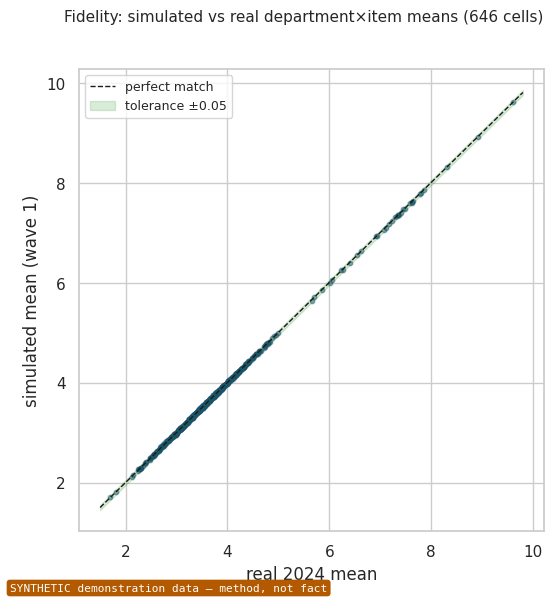

In [4]:
# Fidelity in one picture: every simulated department×item mean vs its real target.
qcols = [c for c in item_map.index if c.startswith("q")]
sim = data[data["wave"] == 1].groupby("department")[qcols].mean()
sim.columns = [item_map.loc[c, "item"] for c in qcols]
sim = sim[targets.columns].reindex(targets.index)   # align to targets

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(targets.to_numpy().ravel(), sim.to_numpy().ravel(),
           s=10, alpha=0.45, color="#1f4e79")
lo, hi = targets.min().min() - 0.2, targets.max().max() + 0.2
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect match")
ax.fill_between([lo, hi], [lo - 0.05, hi - 0.05], [lo + 0.05, hi + 0.05],
                alpha=0.15, color="green", label="tolerance ±0.05")
ax.set_xlabel("real 2024 mean"); ax.set_ylabel("simulated mean (wave 1)")
ax.legend(fontsize=9)
viz.save_figure(fig, "fig05_synthetic_fidelity", cfg, "synthetic",
                "Fidelity: simulated vs real department×item means (646 cells)")
plt.show()

**Read:** gate 1 is a **blocking** check, not a report. Two conditions must hold: every
department × construct cell inside the configured calibration tolerance, and the department
ranking reproduced (Spearman ρ = 1.00). A generator that matched the means while scrambling the
order would be useless for anything a client reads, so matching means alone is not enough.

Passing means the synthetic company matches the source aggregates while adding the
individual-level variation the aggregated data never had. The worst cell and the achieved ρ for
this run are printed above.

---
## C. Gate 2: plausibility and disclosure 

Does the data *behave* like engagement data? Three checks: responses inside their scale bounds;
achieved construct–engagement correlations against the **imposed** targets; and full disclosure
of that imposed structure. **Also blocking.**

In [5]:
pl = synthetic.validate_plausibility(data, item_map, cfg)
print("range violations:", pl["range_violations"] or "none")
print(f"engagement (UWES) block alpha = {pl['engagement_alpha']}  "
      f"(threshold >= {cfg['synthetic']['min_engagement_alpha']})")
print(f"worst |disattenuated − target| = {pl['worst_corr_gap']:.3f}  "
      f"(threshold <= {cfg['synthetic']['max_corr_gap']})")
print(f"items with extreme skew (|skew| > 2): {pl['n_extreme_skew']}")
print(f"GATE {'PASSED' if pl['passed'] else 'FAILED'}")
assert pl["passed"], "Plausibility gate failed — do not model on this data."
pl["achieved_vs_target"]

range violations: none
engagement (UWES) block alpha = 0.71  (threshold >= 0.6)
worst |disattenuated − target| = 0.047  (threshold <= 0.1)
items with extreme skew (|skew| > 2): 0
GATE PASSED


,target_latent_r,achieved_observed_r,alpha,disattenuated_r
construct,,,,
personal,0.48,0.310,0.70,0.442
development,0.45,0.326,0.82,0.429
social,0.36,0.325,0.90,0.407
demands,-0.30,-0.189,0.73,-0.262
satisfaction,0.60,0.454,0.84,0.589
justice,0.30,0.212,0.86,0.272
technology,0.35,0.216,0.68,0.311
psych_safety,0.35,0.228,0.63,0.344
esg,0.25,0.175,0.61,0.266


**Read — the attenuation column is the point.** Observed correlations come out *smaller* than the
imposed latent targets. That is not a generator fault but classical measurement attenuation: short
scales have α well below 1, and observed r ≈ latent r × √(αx·αy). Correcting for it recovers the
targets to within the gate's tolerance, so the copula survived discretisation intact — which is
the difference between a generator that is wrong and one that is merely measured imperfectly.

Two things carry forward: the same attenuation will affect real 2026 data, and the two-item scales
(psychological safety, ESG) attenuate most — the psychometric case for ≥ 4 items per construct
(essay §4.2, §6.3).

In [6]:
# Panel overview: demographics and waves (what the 2024 data does NOT have)
w1 = data[data["wave"] == 1]
overview = pd.DataFrame({
    "employees": [len(w1)], "departments": [w1["department"].nunique()],
    "waves": [data["wave"].nunique()],
    "remote_%": [round((w1["work_mode"] == "remote").mean() * 100, 1)],
    "regions": [w1["region"].nunique()],
})
overview

,employees,departments,waves,remote_%,regions
0,1000,19,3,24.8,5


In [7]:
path = synthetic.save(data, item_map, cfg)
from pathlib import Path
t = Path(cfg["paths"]["tables_dir"]); t.mkdir(parents=True, exist_ok=True)
fid["report"].to_csv(t / "tab13_synthetic_fidelity.csv")
pl["achieved_vs_target"].to_csv(t / "tab14_synthetic_plausibility.csv")
print("saved:", path)
print("generator parameters saved alongside the data (provenance).")

saved: /home/claude/repo/data/synthetic/synthetic_panel.csv
generator parameters saved alongside the data (provenance).


---
## Known limitations of the generator: measured, not asserted

| # | Limitation | Handling |
|---|---|---|
| 1 | 14/646 cells (2.2%) sit at the scale ceiling → within-cell sd collapses to ≈0.15 (typical 0.78), in R and M | Unavoidable when calibrating ordinal data to boundary targets; noted when reading NB05 |
| 2 | `balance` is reverse-keyed `demands` (latent r ≈ −0.97) | Only `balance` enters models, enforced in `DRIVER_CONSTRUCTS` |
| 3 | Items per construct vary 2–14, so α varies 0.62–0.89 and short scales attenuate | Read the disattenuated column; the case for ≥4 items in 2026 |
| 4 | `social` merges manager + team + culture (α 0.89 but coarse) | If `social` ranks top the target is ambiguous; 2026 separates them |
| 5 | Demographics drawn independently of each other and of department | Persona mixes are cleaner than reality would be |
| 6 | I and F share an identical real composite (4.1629); ranking ρ = 1.000 here, ≈0.998 at other seeds | Their order is unidentifiable from 2024 aggregated. |

Properties of the demonstration *data*, not of the method; rows 3–4 feed the RO4 argument.

---
## Handover

Both gates passed. The panel reproduces the 2024 aggregate profile within tolerance, carries
disclosed theory-consistent structure, and contains what the real data lacks: an engagement
outcome, demographics, department sizes and three waves. Modelling may proceed.

**Next:** `05_phase2_modelling.ipynb`.

---
## References

Bakker, A.B. and Demerouti, E. (2017) 'Job demands–resources theory: taking stock and looking
forward', *Journal of Occupational Health Psychology*, 22(3), pp. 273–285.

Edmondson, A. (1999) 'Psychological safety and learning behavior in work teams',
*Administrative Science Quarterly*, 44(2), pp. 350–383.

Lautrup, A.D., Hyrup, T., Zimek, A. and Schneider-Kamp, P. (2025) 'Systematic review of
generative modelling tools and utility metrics for fully synthetic tabular data',
*ACM Computing Surveys*, 57(4), pp. 1–38.

Saks, A.M. (2006) 'Antecedents and consequences of employee engagement', *Journal of
Managerial Psychology*, 21(7), pp. 600–619.

Schaufeli, W.B. and Bakker, A.B. (2004) *UWES – Utrecht Work Engagement Scale: preliminary
manual*. Utrecht: Occupational Health Psychology Unit, Utrecht University.